# Implementación de modelos de Redes Neuronales Profundas

En este archivo, voy a poner en práctica lo aprendido a lo largo de la asignatura tanto en la parte de teoría como en la parte de práctica. La idea es crear una CNN capaz de analizar radiografías de tórax y clasificarlas en tres categorías: pacientes sanos, con neumonía bacteriana y con neumonía vírica.

**Realizado por Rodrigo Gálvez Travalja**

---

## Estructura del notebook
1. Instalación e importación de librerías
2. Comprobación de GPU
3. Descarga del dataset
4. Preprocesamiento e imágenes
5. Definición de la CNN
6. Entrenamiento y validación
7. Predicción y visualización
8. Guardado del modelo

## 1. Instalación e importación de librerías

In [1]:
%pip install torch torchvision kagglehub matplotlib pandas scikit-learn --quiet

import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

import kagglehub

# Añadir raíz del proyecto al path para importar desde app/
sys.path.insert(0, os.path.abspath('..'))

# Importar arquitectura de modelo desde app/model/architecture.py
from app.model.architecture import PneumoniaCNN, CLASS_NAMES

print('Librerías importadas correctamente.')

Note: you may need to restart the kernel to use updated packages.
Librerías importadas correctamente.


/Users/rodrigo/Library/Python/3.13/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Comprobación de GPU y configuración del device

In [2]:
# Verificar disponibilidad de CUDA/MPS y seleccionar device
print(f'Versión de PyTorch: {torch.__version__}')
print(f'CUDA disponible:    {torch.cuda.is_available()}')
print(f'MPS disponible:     {torch.backends.mps.is_available()}')

if torch.cuda.is_available():
    print(f'GPU (CUDA):         {torch.cuda.get_device_name(0)}')
    print(f'Versión CUDA:       {torch.version.cuda}')
elif torch.backends.mps.is_available():
    print(f'GPU (MPS):          Apple Silicon')

# Prioridad: CUDA (Windows/Linux con GPU) → MPS (Mac Apple Silicon) → CPU
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'\nUsando device: {device}')

Versión de PyTorch: 2.11.0
CUDA disponible:    False
MPS disponible:     True
GPU (MPS):          Apple Silicon

Usando device: mps


In [3]:
# Configuración global: tamaño de imagen y normalización
TAMANIO_IMAGEN = (100, 100)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Usar CLASS_NAMES importado de la arquitectura: garantiza consistencia con el wrapper de inferencia
NOMBRES_CLASES = CLASS_NAMES  # ['NORMAL', 'PNEUMONIA_BACTERIAL', 'PNEUMONIA_VIRAL']

print(f'Tamaño de imagen: {TAMANIO_IMAGEN}')
print(f'Clases: {NOMBRES_CLASES}')

Tamaño de imagen: (100, 100)
Clases: ['NORMAL', 'PNEUMONIA_BACTERIAL', 'PNEUMONIA_VIRAL']


## 3. Descarga del dataset desde Kaggle

In [4]:
# Descarga del dataset Chest X-Ray Images (Pneumonia)
ruta = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print(f'Dataset descargado en: {ruta}')

# Rutas a los splits del dataset
ruta_datos    = os.path.join(ruta, 'chest_xray')
RUTA_TRAIN    = os.path.join(ruta_datos, 'train')
RUTA_VAL      = os.path.join(ruta_datos, 'val')
RUTA_TEST     = os.path.join(ruta_datos, 'test')   # minúsculas: Linux es case-sensitive

# Verificar que las carpetas existen
for nombre, ruta_split in [('train', RUTA_TRAIN), ('val', RUTA_VAL), ('test', RUTA_TEST)]:
    existe = os.path.isdir(ruta_split)
    print(f'  {nombre}: {ruta_split} → {"OK" if existe else "NO ENCONTRADA"}')

Dataset descargado en: /Users/rodrigo/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
  train: /Users/rodrigo/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/train → OK
  val: /Users/rodrigo/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/val → OK
  test: /Users/rodrigo/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2/chest_xray/test → OK


## 4. Preprocesamiento e imágenes

El dataset de Kaggle organiza las imágenes en dos carpetas: `NORMAL` y `PNEUMONIA`.
Dentro de `PNEUMONIA`, el nombre del fichero indica si es bacteriana (`bacteria`) o vírica (`virus`).
Creamos un Dataset personalizado que lee esta estructura y asigna las etiquetas correctas para la clasificación en 3 clases.

In [5]:
# Transformaciones para entrenamiento (con data augmentation)
transformacion_entrenamiento = transforms.Compose([
    transforms.Resize(TAMANIO_IMAGEN),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

## 5. Definición de la CNN

Arquitectura de 3 bloques convolucionales seguidos de capas fully connected.
Cada bloque aplica Conv2d + ReLU + MaxPool2d(2,2), reduciendo la resolución a la mitad.
Con input 100×100: 100 → 50 → 25 → 12, por lo que la capa FC recibe 128 × 12 × 12 = 18432 características.

In [6]:
# PneumoniaCNN ya está importada en la celda de importaciones
# Misma clase que usa el wrapper de inferencia → garantiza consistencia total
modelo = PneumoniaCNN(num_classes=3).to(device)
print(modelo)

total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {total_params:,}')

PneumoniaCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=18432, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

Parámetros entrenables: 2,453,059


In [7]:
# Dataset personalizado para cargar radiografías desde estructura Kaggle
class DatasetRayosX(Dataset):
    """
    Dataset personalizado para radiografías de tórax.
    Lee estructura típica Kaggle:
      train/NORMAL/*
      train/PNEUMONIA/bacteria/* or train/PNEUMONIA/virus/*
    Y también maneja imágenes directamente en train/PNEUMONIA/ con nombres que incluyen 'bacteria' o 'virus'.
    """
    def __init__(self, ruta_raiz, transformaciones=None):
        self.imagenes = []
        self.etiquetas = []
        self.transformaciones = transformaciones

        # Clase 0: NORMAL
        ruta_normal = os.path.join(ruta_raiz, 'NORMAL')
        if os.path.exists(ruta_normal):
            for imagen in glob.glob(os.path.join(ruta_normal, '*')):
                if os.path.isfile(imagen):
                    self.imagenes.append(imagen)
                    self.etiquetas.append(0)

        # Clase 1 y 2: PNEUMONIA (subcarpetas bacteria / virus) o archivos directos
        ruta_pneumonia = os.path.join(ruta_raiz, 'PNEUMONIA')
        if os.path.exists(ruta_pneumonia):
            # 1) Archivos directamente bajo PNEUMONIA/
            archivos_root = [p for p in glob.glob(os.path.join(ruta_pneumonia, '*')) if os.path.isfile(p)]
            añadidos_root = 0
            for imagen in archivos_root:
                nombre = os.path.basename(imagen).lower()
                if 'virus' in nombre or 'viral' in nombre:
                    etiq = 2
                elif 'bacteria' in nombre:
                    etiq = 1
                else:
                    continue
                self.imagenes.append(imagen)
                self.etiquetas.append(etiq)
                añadidos_root += 1

            # 2) Subdirectorios dentro de PNEUMONIA/
            añadidos_subdirs = 0
            for entrada in os.listdir(ruta_pneumonia):
                path_entrada = os.path.join(ruta_pneumonia, entrada)
                if not os.path.isdir(path_entrada):
                    continue
                name_lower = entrada.lower()
                if 'bacteria' in name_lower:
                    etiq_dir = 1
                elif 'virus' in name_lower or 'viral' in name_lower:
                    etiq_dir = 2
                else:
                    etiq_dir = None  # se inferirá por nombre de fichero

                for imagen in glob.glob(os.path.join(path_entrada, '*')):
                    if not os.path.isfile(imagen):
                        continue
                    # Usar etiqueta del directorio si está clara; si no, inferir del nombre del fichero
                    if etiq_dir is not None:
                        etiq = etiq_dir
                    else:
                        img_lower = os.path.basename(imagen).lower()
                        if 'virus' in img_lower or 'viral' in img_lower:
                            etiq = 2
                        elif 'bacteria' in img_lower:
                            etiq = 1
                        else:
                            continue
                    self.imagenes.append(imagen)
                    self.etiquetas.append(etiq)
                    añadidos_subdirs += 1

            if añadidos_root > 0:
                print(f'Nota: se añadieron {añadidos_root} imágenes encontradas directamente en PNEUMONIA/')
            if añadidos_subdirs == 0 and añadidos_root == 0:
                print('⚠️ Aviso: no se encontraron imágenes en PNEUMONIA/ (ni en subcarpetas ni en raíz)')

    def __len__(self):
        return len(self.imagenes)

    def __getitem__(self, idx):
        imagen = Image.open(self.imagenes[idx]).convert('RGB')
        if self.transformaciones:
            imagen = self.transformaciones(imagen)
        return imagen, self.etiquetas[idx]


class DatasetDesdeListas(Dataset):
    """Dataset que construye un split a partir de listas de rutas y etiquetas ya filtradas."""
    def __init__(self, imagenes, etiquetas, transformaciones=None):
        self.imagenes = imagenes
        self.etiquetas = etiquetas
        self.transformaciones = transformaciones

    def __len__(self):
        return len(self.imagenes)

    def __getitem__(self, idx):
        imagen = Image.open(self.imagenes[idx]).convert('RGB')
        if self.transformaciones:
            imagen = self.transformaciones(imagen)
        return imagen, self.etiquetas[idx]


# === Split manual 80/20 desde el pool completo ===
# El val de Kaggle solo tiene 16 imágenes: demasiado pequeño para early stopping.
# Solución: combinar train + val de Kaggle y hacer un split estratificado 80/20.

pool_train      = DatasetRayosX(RUTA_TRAIN, transformaciones=None)
pool_val_kaggle = DatasetRayosX(RUTA_VAL,   transformaciones=None)

todas_imagenes  = pool_train.imagenes  + pool_val_kaggle.imagenes
todas_etiquetas = pool_train.etiquetas + pool_val_kaggle.etiquetas

print(f'Pool total: {len(todas_imagenes)} imágenes')
contador_pool = Counter(todas_etiquetas)
print(f'Distribución: { {NOMBRES_CLASES[k]: v for k, v in sorted(contador_pool.items())} }')

# Split estratificado para que cada clase esté representada proporcionalmente
indices = list(range(len(todas_imagenes)))
idx_train, idx_val = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=todas_etiquetas
)

imagenes_train  = [todas_imagenes[i]  for i in idx_train]
etiquetas_train = [todas_etiquetas[i] for i in idx_train]
imagenes_val    = [todas_imagenes[i]  for i in idx_val]
etiquetas_val   = [todas_etiquetas[i] for i in idx_val]

transformacion_val = transforms.Compose([
    transforms.Resize(TAMANIO_IMAGEN),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

dataset_train = DatasetDesdeListas(imagenes_train, etiquetas_train, transformacion_entrenamiento)
dataset_val   = DatasetDesdeListas(imagenes_val,   etiquetas_val,   transformacion_val)

print(f'\nSplit 80/20 estratificado:')
print(f'  Train: {len(dataset_train)} imágenes')
print(f'  Val:   {len(dataset_val)} imágenes')

# Distribución por clase del split de train
contador_train = Counter(etiquetas_train)
print(f'\nDistribución clases (train split):')
for i, clase in enumerate(NOMBRES_CLASES):
    print(f'  {clase}: {contador_train.get(i, 0)}')

# Dataloaders
loader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
loader_val   = DataLoader(dataset_val,   batch_size=32, shuffle=False)

print(f'\nBatches train: {len(loader_train)}')
print(f'Batches val:   {len(loader_val)}')

# Calcular pesos de clases (inverso de frecuencia) sobre el split de train
counts = [contador_train.get(i, 0) for i in range(3)]
total_samples = sum(counts)
pesos = [total_samples / (max(c, 1) * 3) for c in counts]
pesos_clases = torch.tensor(pesos, dtype=torch.float32)

print(f'\nPesos de clases (corrección desbalanceo):')
for i, (clase, peso, c) in enumerate(zip(NOMBRES_CLASES, pesos_clases, counts)):
    print(f'  {clase}: peso = {peso:.4f} (n={c})')

Nota: se añadieron 3875 imágenes encontradas directamente en PNEUMONIA/
Nota: se añadieron 8 imágenes encontradas directamente en PNEUMONIA/
Pool total: 5232 imágenes
Distribución: {'NORMAL': 1349, 'PNEUMONIA_BACTERIAL': 2538, 'PNEUMONIA_VIRAL': 1345}

Split 80/20 estratificado:
  Train: 4185 imágenes
  Val:   1047 imágenes

Distribución clases (train split):
  NORMAL: 1079
  PNEUMONIA_BACTERIAL: 2030
  PNEUMONIA_VIRAL: 1076

Batches train: 131
Batches val:   33

Pesos de clases (corrección desbalanceo):
  NORMAL: peso = 1.2929 (n=1079)
  PNEUMONIA_BACTERIAL: peso = 0.6872 (n=2030)
  PNEUMONIA_VIRAL: peso = 1.2965 (n=1076)


In [8]:
# Preparar dataset y dataloader de test (antes de llamar a evaluar_en_test)
dataset_test = DatasetRayosX(RUTA_TEST, transforms.Compose([
    transforms.Resize(TAMANIO_IMAGEN),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
]))
loader_test = DataLoader(dataset_test, batch_size=32, shuffle=False)
print(f'Dataset test: {len(dataset_test)} imágenes — Batches: {len(loader_test)}')


Nota: se añadieron 390 imágenes encontradas directamente en PNEUMONIA/
Dataset test: 624 imágenes — Batches: 20


## 6. Entrenamiento y validación

Criterio de selección del mejor modelo: **Balanced Accuracy** (promedio de recall por clase).
Esto evita que el modelo se optimice para la clase mayoritaria (PNEUMONIA_BACTERIAL) a costa de las otras.

Hiperparámetros:
- `lr=0.0005` — conservador para evitar oscilaciones entre épocas.
- `ReduceLROnPlateau(patience=3, factor=0.5)` — reduce el LR a la mitad si Bal.Acc no mejora en 3 épocas, suavizando la convergencia.
- Early stopping con `patience=7` — espera 7 épocas sin mejora antes de detener, dando margen al scheduler para actuar.

In [9]:
import copy

def entrenar_modelo(modelo, loader_train, loader_val, pesos_clases, num_epocas=30, lr=0.0005, patience=7):
    """
    Entrena el modelo y evalúa en validación cada época.

    Criterio de selección: Balanced Accuracy (promedio de recall por clase).
    Esto penaliza cuando cualquier clase baja su recall, evitando overfitting
    a la clase mayoritaria — especialmente importante en clasificación médica.

    Estabilidad de curvas:
    - lr=0.0005 (más conservador que 0.001) reduce los saltos entre épocas.
    - ReduceLROnPlateau reduce el LR a la mitad si Bal.Acc no mejora en 3 épocas,
      permitiendo convergencia progresiva en lugar de rebotar alrededor del mínimo.

    Args:
        pesos_clases: Tensor con pesos por clase para CrossEntropyLoss.
        patience: Épocas sin mejora en Balanced Accuracy antes de parar.

    Returns:
        modelo, perdidas_train, perdidas_val, precisiones_train, precisiones_val, balanced_accs_val, lrs_por_epoca
    """
    from sklearn.metrics import recall_score

    optimizador = optim.RMSprop(modelo.parameters(), lr=lr)
    criterio    = nn.CrossEntropyLoss(weight=pesos_clases.to(device))

    # Scheduler: reduce LR x0.5 si Balanced Accuracy no mejora en 3 épocas consecutivas
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizador, mode='max', factor=0.5, patience=3
    )

    perdidas_train,    perdidas_val    = [], []
    precisiones_train, precisiones_val = [], []
    balanced_accs_val = []
    lrs_por_epoca     = []

    mejor_bal_acc     = 0.0
    epocas_sin_mejora = 0
    mejor_epoca       = 0
    mejor_checkpoint  = None

    for epoca in range(num_epocas):

        # --- Fase de entrenamiento ---
        modelo.train()
        perdida_acum = 0.0
        correctos    = 0
        total        = 0

        for entradas, etiquetas in loader_train:
            entradas  = entradas.to(device)
            etiquetas = etiquetas.to(device)

            optimizador.zero_grad()
            salidas = modelo(entradas)
            perdida = criterio(salidas, etiquetas)
            perdida.backward()
            optimizador.step()

            perdida_acum += perdida.item()
            _, predicho   = torch.max(salidas, 1)
            correctos     += (predicho == etiquetas).sum().item()
            total         += etiquetas.size(0)

        loss_train = perdida_acum / len(loader_train)
        acc_train  = 100 * correctos / total
        perdidas_train.append(loss_train)
        precisiones_train.append(acc_train)

        # --- Fase de validación ---
        modelo.eval()
        todas_pred_val = []
        todas_etiq_val = []
        perdida_val_acum = 0.0

        with torch.no_grad():
            for entradas, etiquetas in loader_val:
                entradas  = entradas.to(device)
                etiquetas = etiquetas.to(device)

                salidas = modelo(entradas)
                perdida = criterio(salidas, etiquetas)

                perdida_val_acum += perdida.item()
                _, predicho = torch.max(salidas, 1)
                todas_pred_val.extend(predicho.cpu().numpy())
                todas_etiq_val.extend(etiquetas.cpu().numpy())

        loss_val = perdida_val_acum / len(loader_val)
        acc_val  = 100 * sum(p == e for p, e in zip(todas_pred_val, todas_etiq_val)) / len(todas_etiq_val)

        recalls_por_clase = recall_score(todas_etiq_val, todas_pred_val, average=None, zero_division=0)
        balanced_acc = np.mean(recalls_por_clase) * 100

        perdidas_val.append(loss_val)
        precisiones_val.append(acc_val)
        balanced_accs_val.append(balanced_acc)

        # Registrar LR antes de que el scheduler lo modifique
        lr_actual = optimizador.param_groups[0]['lr']
        lrs_por_epoca.append(lr_actual)

        # Actualizar scheduler con la métrica de validación
        scheduler.step(balanced_acc)

        # Guardar checkpoint con deepcopy para aislar los pesos del entrenamiento posterior
        marca_mejor = ""
        if balanced_acc > mejor_bal_acc:
            mejor_bal_acc     = balanced_acc
            epocas_sin_mejora = 0
            mejor_epoca       = epoca + 1
            mejor_checkpoint  = copy.deepcopy(modelo.state_dict())
            marca_mejor       = " ⭐ MEJOR"
        else:
            epocas_sin_mejora += 1

        print(f'Época {epoca+1:02d}/{num_epocas} | LR: {lr_actual:.6f} | '
              f'Loss train: {loss_train:.4f}  Acc train: {acc_train:.2f}% | '
              f'Acc val: {acc_val:.2f}%  Bal.Acc: {balanced_acc:.2f}%{marca_mejor}')

        if (epoca + 1) % 5 == 0 or marca_mejor:
            for i, recall_i in enumerate(recalls_por_clase):
                print(f'           → {NOMBRES_CLASES[i]}: recall = {recall_i*100:.2f}%')

        if epocas_sin_mejora >= patience:
            print(f'\n🛑 Early stopping: Balanced Accuracy sin mejora durante {patience} épocas.')
            print(f'   Mejor modelo guardado en época {mejor_epoca} con Bal.Acc = {mejor_bal_acc:.2f}%')
            break

    if mejor_checkpoint is not None:
        modelo.load_state_dict(mejor_checkpoint)
        print(f'\n✓ Mejor modelo cargado (época {mejor_epoca}, Bal.Acc = {mejor_bal_acc:.2f}%)')
    else:
        print('\n⚠️ No se guardó checkpoint (mejor_checkpoint es None)')

    return modelo, perdidas_train, perdidas_val, precisiones_train, precisiones_val, balanced_accs_val, lrs_por_epoca


modelo, perdidas_train, perdidas_val, precisiones_train, precisiones_val, balanced_accs_val, lrs_por_epoca = entrenar_modelo(
    modelo, loader_train, loader_val, pesos_clases, num_epocas=30, lr=0.0005, patience=7
)

Época 01/30 | LR: 0.000500 | Loss train: 0.8435  Acc train: 63.01% | Acc val: 74.40%  Bal.Acc: 74.21% ⭐ MEJOR
           → NORMAL: recall = 88.15%
           → PNEUMONIA_BACTERIAL: recall = 75.00%
           → PNEUMONIA_VIRAL: recall = 59.48%
Época 02/30 | LR: 0.000500 | Loss train: 0.5894  Acc train: 71.25% | Acc val: 78.22%  Bal.Acc: 76.53% ⭐ MEJOR
           → NORMAL: recall = 96.67%
           → PNEUMONIA_BACTERIAL: recall = 83.86%
           → PNEUMONIA_VIRAL: recall = 49.07%
Época 03/30 | LR: 0.000500 | Loss train: 0.5437  Acc train: 74.19% | Acc val: 78.32%  Bal.Acc: 78.11% ⭐ MEJOR
           → NORMAL: recall = 99.26%
           → PNEUMONIA_BACTERIAL: recall = 78.94%
           → PNEUMONIA_VIRAL: recall = 56.13%
Época 04/30 | LR: 0.000500 | Loss train: 0.5312  Acc train: 75.65% | Acc val: 78.61%  Bal.Acc: 77.61%
Época 05/30 | LR: 0.000500 | Loss train: 0.5082  Acc train: 76.61% | Acc val: 76.60%  Bal.Acc: 77.05%
           → NORMAL: recall = 99.26%
           → PNEUMONIA_BACTERI

## 7. Visualización de métricas de entrenamiento

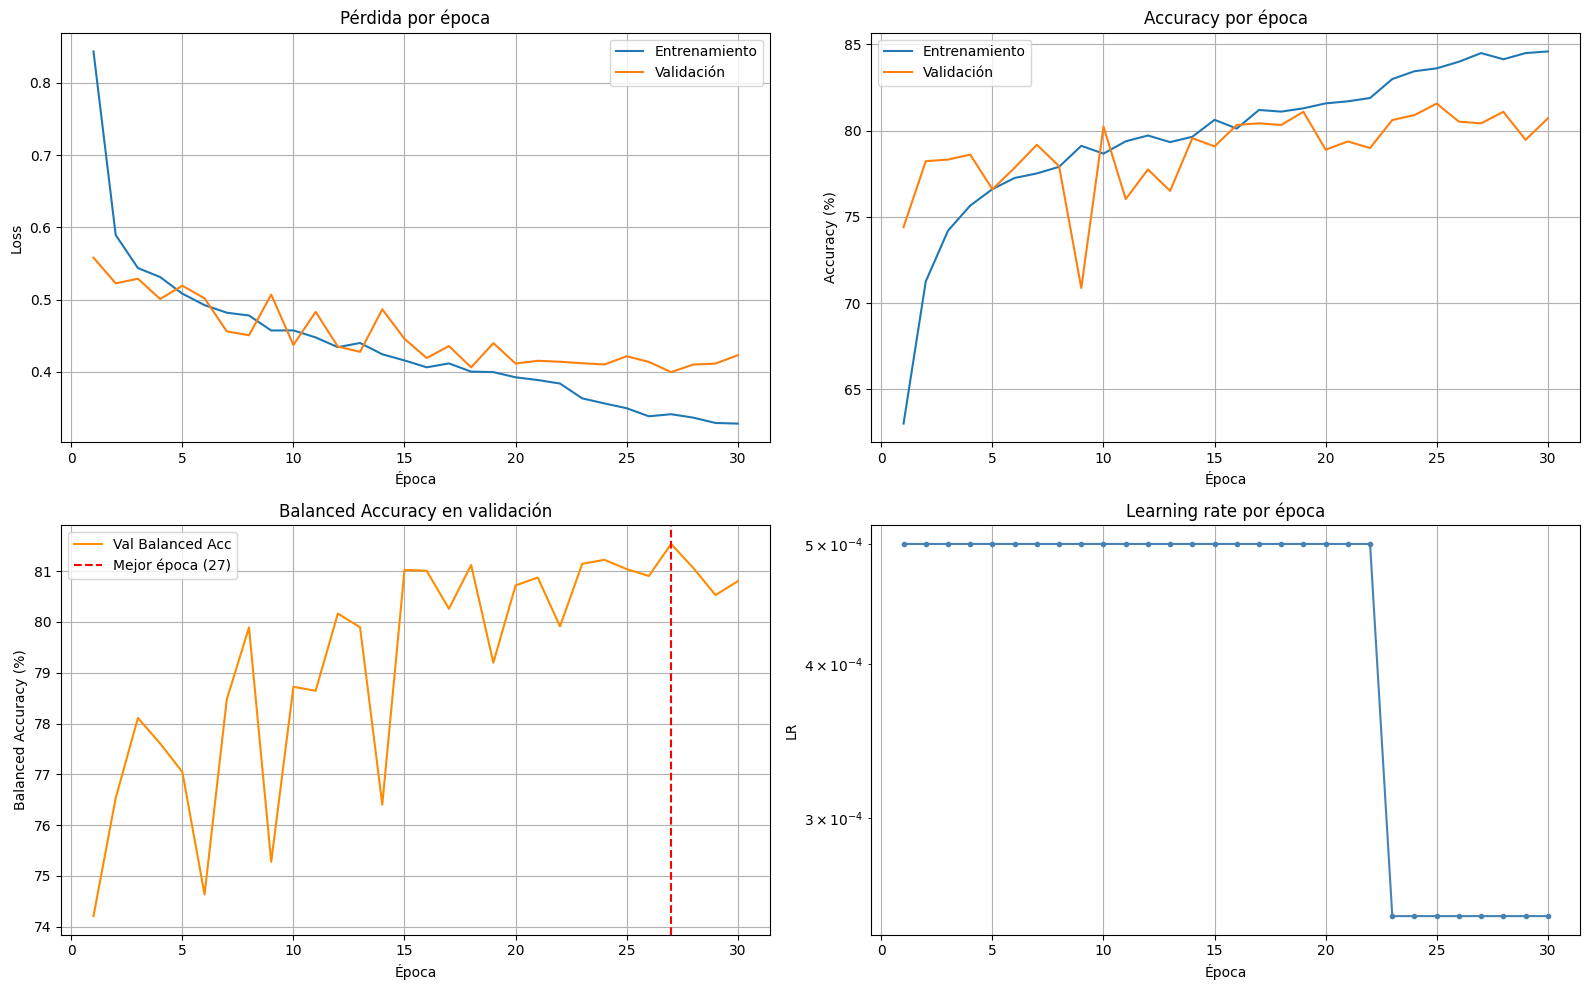

In [10]:
def mostrar_graficas(perdidas_train, perdidas_val, precisiones_train, precisiones_val, balanced_accs_val, lrs_por_epoca):
    """Muestra loss, accuracy, balanced accuracy y evolución del learning rate."""
    epocas = range(1, len(perdidas_train) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Pérdida
    ax = axes[0, 0]
    ax.plot(epocas, perdidas_train, label='Entrenamiento')
    ax.plot(epocas, perdidas_val,   label='Validación')
    ax.set_title('Pérdida por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

    # Accuracy estándar
    ax = axes[0, 1]
    ax.plot(epocas, precisiones_train, label='Entrenamiento')
    ax.plot(epocas, precisiones_val,   label='Validación')
    ax.set_title('Accuracy por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True)

    # Balanced Accuracy en validación (métrica de selección)
    ax = axes[1, 0]
    ax.plot(epocas, balanced_accs_val, color='darkorange', label='Val Balanced Acc')
    mejor_idx = int(np.argmax(balanced_accs_val))
    ax.axvline(x=mejor_idx + 1, color='red', linestyle='--', label=f'Mejor época ({mejor_idx + 1})')
    ax.set_title('Balanced Accuracy en validación')
    ax.set_xlabel('Época')
    ax.set_ylabel('Balanced Accuracy (%)')
    ax.legend()
    ax.grid(True)

    # Learning rate por época (confirma actuaciones del scheduler)
    ax = axes[1, 1]
    ax.plot(epocas, lrs_por_epoca, color='steelblue', marker='o', markersize=3)
    ax.set_title('Learning rate por época')
    ax.set_xlabel('Época')
    ax.set_ylabel('LR')
    ax.set_yscale('log')
    ax.grid(True)

    plt.tight_layout()
    plt.show()


mostrar_graficas(perdidas_train, perdidas_val, precisiones_train, precisiones_val, balanced_accs_val, lrs_por_epoca)

## 8. Evaluación sobre el conjunto de test

Evaluación completa: accuracy global, métricas por clase (precision, recall, F1) y matriz de confusión.

Accuracy en test: 72.60%

                     precision    recall  f1-score   support

             NORMAL       0.98      0.47      0.64       234
PNEUMONIA_BACTERIAL       0.87      0.88      0.88       242
    PNEUMONIA_VIRAL       0.48      0.86      0.62       148

           accuracy                           0.73       624
          macro avg       0.78      0.74      0.71       624
       weighted avg       0.82      0.73      0.73       624



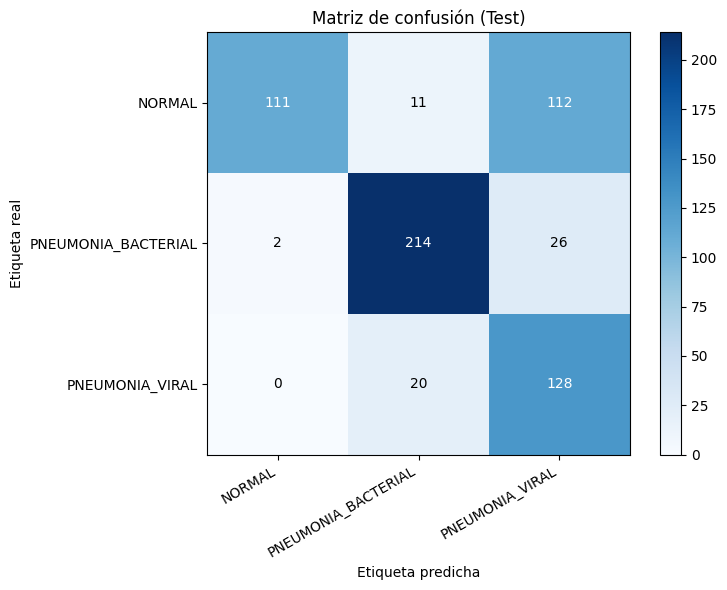


--- Ejemplos de predicciones individuales ---


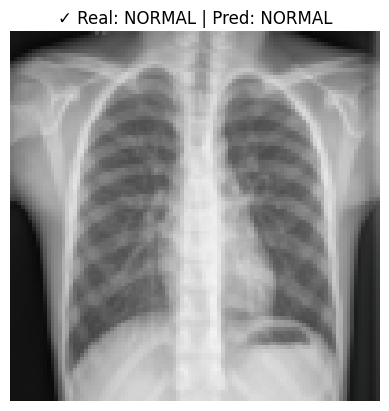

  NORMAL                    89.71%
  PNEUMONIA_VIRAL           8.33%
  PNEUMONIA_BACTERIAL       1.96%
----------------------------------------


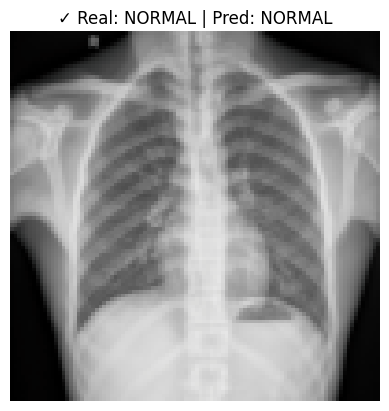

  NORMAL                    99.83%
  PNEUMONIA_VIRAL           0.15%
  PNEUMONIA_BACTERIAL       0.02%
----------------------------------------


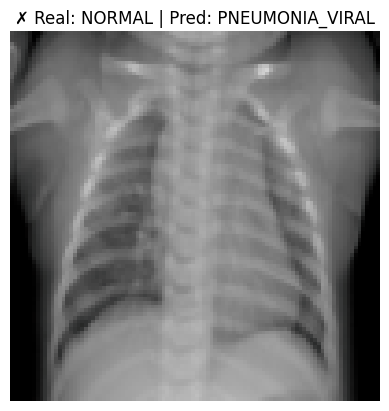

  PNEUMONIA_VIRAL           47.59%
  NORMAL                    41.81%
  PNEUMONIA_BACTERIAL       10.60%
----------------------------------------


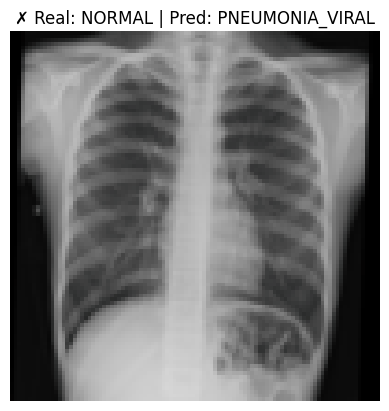

  PNEUMONIA_VIRAL           77.26%
  NORMAL                    18.64%
  PNEUMONIA_BACTERIAL       4.10%
----------------------------------------


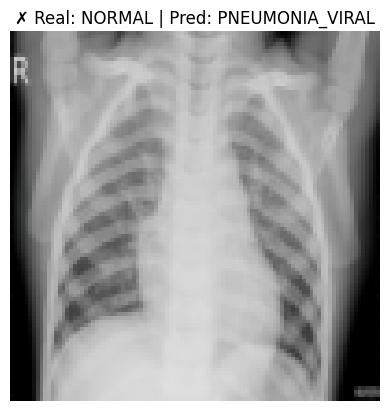

  PNEUMONIA_VIRAL           93.35%
  PNEUMONIA_BACTERIAL       5.40%
  NORMAL                    1.26%
----------------------------------------


In [11]:
# Definir función de desnormalización como helper global
def desnormalizar_imagen(tensor_normalizado, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Desnormaliza un tensor normalizado con ImageNet stats."""
    tensor = tensor_normalizado.clone()
    for i, (m, s) in enumerate(zip(mean, std)):
        tensor[i] = tensor[i] * s + m
    return torch.clamp(tensor, 0, 1)


def evaluar_en_test(modelo, loader_test, nombres_clases):
    """Calcula accuracy, métricas por clase y matriz de confusión sobre el test set."""
    
    modelo.eval()
    todas_predicciones = []
    todas_etiquetas    = []

    with torch.no_grad():
        for entradas, etiquetas in loader_test:
            entradas = entradas.to(device)
            salidas  = modelo(entradas)
            _, predicho = torch.max(salidas, 1)
            todas_predicciones.extend(predicho.cpu().numpy())
            todas_etiquetas.extend(etiquetas.numpy())

    # Accuracy global
    acc = 100 * sum(p == e for p, e in zip(todas_predicciones, todas_etiquetas)) / len(todas_etiquetas)
    print(f'Accuracy en test: {acc:.2f}%\n')

    # Métricas por clase: precision, recall, F1
    print(classification_report(todas_etiquetas, todas_predicciones, target_names=nombres_clases))

    # Matriz de confusión
    cm = confusion_matrix(todas_etiquetas, todas_predicciones)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Matriz de confusión (Test)')
    plt.colorbar()
    tick_marks = range(len(nombres_clases))
    plt.xticks(tick_marks, nombres_clases, rotation=30, ha='right')
    plt.yticks(tick_marks, nombres_clases)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

    plt.ylabel('Etiqueta real')
    plt.xlabel('Etiqueta predicha')
    plt.tight_layout()
    plt.show()


evaluar_en_test(modelo, loader_test, NOMBRES_CLASES)

# Mostrar algunas predicciones individuales con probabilidades (DESNORMALIZADAS)
print('\n--- Ejemplos de predicciones individuales ---')
modelo.eval()
mostradas = 0
with torch.no_grad():
    for entradas, etiquetas in loader_test:
        entradas = entradas.to(device)
        salidas  = modelo(entradas)
        probs    = F.softmax(salidas, dim=1).cpu().numpy()

        for i in range(entradas.size(0)):
            if mostradas >= 5:
                break
            prob_imagen = probs[i]
            clase_pred  = NOMBRES_CLASES[np.argmax(prob_imagen)]
            clase_real  = NOMBRES_CLASES[etiquetas[i].item()]
            orden       = np.argsort(prob_imagen)[::-1]

            # Desnormalizar la imagen antes de visualizar
            tensor_desnorm = desnormalizar_imagen(entradas[i].cpu())
            imagen = to_pil_image(tensor_desnorm)
            plt.imshow(imagen, cmap='gray')
            plt.axis('off')
            acierto = '✓' if clase_pred == clase_real else '✗'
            plt.title(f'{acierto} Real: {clase_real} | Pred: {clase_pred}')
            plt.show()

            for idx in orden:
                print(f'  {NOMBRES_CLASES[idx]:<25} {prob_imagen[idx]*100:.2f}%')
            print('-' * 40)
            mostradas += 1

        if mostradas >= 5:
            break

## 9. Guardado del modelo    

Guardamos el `state_dict` junto con metadatos del modelo para que el wrapper de inferencia pueda cargarlo correctamente.

In [12]:
# Ruta de guardado relativa al proyecto
RUTA_MODELO = os.path.join('..', 'models', 'model.pth')
os.makedirs(os.path.dirname(RUTA_MODELO), exist_ok=True)

# Guardar state_dict + metadatos necesarios para el wrapper de inferencia
checkpoint = {
    'state_dict':     modelo.state_dict(),
    'num_clases':     3,
    'nombres_clases': NOMBRES_CLASES,
    'tamanio_imagen': TAMANIO_IMAGEN,
    'arquitectura':   'PneumoniaCNN'
}

torch.save(checkpoint, RUTA_MODELO)

tamanio_kb = os.path.getsize(RUTA_MODELO) / 1024
print(f'Modelo guardado en: {RUTA_MODELO}')
print(f'Tamaño del archivo: {tamanio_kb:.1f} KB')

# Verificación: cargar y hacer un forward pass de prueba
print('\nVerificando carga del modelo...')
checkpoint_cargado = torch.load(RUTA_MODELO, map_location='cpu', weights_only=False)
modelo_verificacion = PneumoniaCNN(num_classes=3)
modelo_verificacion.load_state_dict(checkpoint_cargado['state_dict'])
modelo_verificacion.eval()

tensor_prueba = torch.randn(1, 3, 100, 100)
with torch.no_grad():
    salida = modelo_verificacion(tensor_prueba)

print(f'Output shape: {list(salida.shape)}  ← esperado [1, 3]')
print('Modelo guardado y verificado correctamente.')

Modelo guardado en: ../models/model.pth
Tamaño del archivo: 9585.9 KB

Verificando carga del modelo...
Output shape: [1, 3]  ← esperado [1, 3]
Modelo guardado y verificado correctamente.
